<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Gemini API and VertexAI</h1>
<h1>Text Generation</h1>
        <p>Bruno Gon&#231;alves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
from collections import Counter
from pprint import pprint
import os
import json
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import google.generativeai as genai

import watermark
%load_ext watermark
%matplotlib inline

/Users/bgoncalves/My Drive/DataForScience/GeminiAI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/lr/j1bs1q851k15cj5y777nxwph0000gn/T/ipykernel_58328/719628195.py:11: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


We start by printing out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.10.0

Compiler    : Clang 17.0.0 (clang-1700.0.13.3)
OS          : Darwin
Release     : 25.3.0
Machine     : arm64
Processor   : arm
CPU cores   : 16
Architecture: 64bit

Git hash: 35408313b88b01f7752e4d04d548a3ef76736752

json      : 2.0.9
matplotlib: 3.10.8
numpy     : 2.4.2
pandas    : 3.0.1
re        : 2.2.1
watermark : 2.6.0



Load default figure style

In [ ]:
plt.style.use('d4sci.mplstyle')

# Section 1: Prompt Engineering for Text Models

Prompt engineering is the practice of crafting effective inputs to guide large language models toward desired outputs. The quality and structure of your prompt dramatically affect the quality of the model's response. In this section we explore the main prompting strategies you will use day-to-day.

## 1.1 Zero-Shot Prompting

In **zero-shot** prompting you ask the model a question or give it a task with no worked examples. The model must rely entirely on its pre-trained knowledge. This is the simplest and most common prompting strategy.

In [4]:
# Zero-shot prompts: ask directly, no examples provided
zero_shot_prompts = {
    "classification": (
        "Classify the sentiment of the following sentence as Positive, Negative, or Neutral.\n"
        "Sentence: The new software update completely broke my workflow and I lost three hours of work."
    ),
    "translation": (
        "Translate the following sentence to French:\n"
        "Artificial intelligence is transforming every industry."
    ),
    "summarization": (
        "Summarize the following paragraph in one sentence:\n"
        "Machine learning models are trained on large datasets to identify patterns and make predictions. "
        "Once trained, these models can generalize to new, unseen data. Deep learning, a subset of machine "
        "learning, uses neural networks with many layers to learn hierarchical representations of data, "
        "achieving state-of-the-art results on tasks like image recognition and natural language processing."
    ),
}

for strategy, prompt in zero_shot_prompts.items():
    print(f"--- {strategy.upper()} ---")
    print("PROMPT:")
    print(prompt)
    print()

--- CLASSIFICATION ---
PROMPT:
Classify the sentiment of the following sentence as Positive, Negative, or Neutral.
Sentence: The new software update completely broke my workflow and I lost three hours of work.

--- TRANSLATION ---
PROMPT:
Translate the following sentence to French:
Artificial intelligence is transforming every industry.

--- SUMMARIZATION ---
PROMPT:
Summarize the following paragraph in one sentence:
Machine learning models are trained on large datasets to identify patterns and make predictions. Once trained, these models can generalize to new, unseen data. Deep learning, a subset of machine learning, uses neural networks with many layers to learn hierarchical representations of data, achieving state-of-the-art results on tasks like image recognition and natural language processing.



## 1.2 Few-Shot Prompting

**Few-shot** prompting provides the model with a small number of input-output examples before the actual query. The examples act as an in-context learning signal, showing the model the expected format and reasoning style.

In [5]:
# Few-shot prompt: provide labelled examples before the target query
few_shot_sentiment_prompt = """\
Classify the sentiment of each sentence as Positive, Negative, or Neutral.

Sentence: I absolutely love the new interface — it's clean and intuitive.
Sentiment: Positive

Sentence: The product arrived on time and works as expected.
Sentiment: Neutral

Sentence: I'm extremely disappointed; the battery died after two hours.
Sentiment: Negative

Sentence: The customer support team resolved my issue within minutes!
Sentiment:"""

print("FEW-SHOT SENTIMENT PROMPT:")
print(few_shot_sentiment_prompt)

# Few-shot prompt for entity extraction
few_shot_ner_prompt = """\
Extract the person names and organizations from each sentence.

Sentence: Elon Musk founded SpaceX in 2002.
People: Elon Musk
Organizations: SpaceX

Sentence: Sundar Pichai has been CEO of Google since 2015.
People: Sundar Pichai
Organizations: Google

Sentence: Sam Altman leads OpenAI, which was co-founded by Greg Brockman.
People:"""

print("\nFEW-SHOT NER PROMPT:")
print(few_shot_ner_prompt)

FEW-SHOT SENTIMENT PROMPT:
Classify the sentiment of each sentence as Positive, Negative, or Neutral.

Sentence: I absolutely love the new interface — it's clean and intuitive.
Sentiment: Positive

Sentence: The product arrived on time and works as expected.
Sentiment: Neutral

Sentence: I'm extremely disappointed; the battery died after two hours.
Sentiment: Negative

Sentence: The customer support team resolved my issue within minutes!
Sentiment:

FEW-SHOT NER PROMPT:
Extract the person names and organizations from each sentence.

Sentence: Elon Musk founded SpaceX in 2002.
People: Elon Musk
Organizations: SpaceX

Sentence: Sundar Pichai has been CEO of Google since 2015.
People: Sundar Pichai
Organizations: Google

Sentence: Sam Altman leads OpenAI, which was co-founded by Greg Brockman.
People:


## 1.3 Chain-of-Thought (CoT) Prompting

**Chain-of-thought** prompting encourages the model to reason step-by-step before producing a final answer. This dramatically improves performance on tasks that require multi-step reasoning, arithmetic, or logical deduction. You can trigger CoT with phrases like *"Let's think step by step"* or by providing CoT examples.

In [6]:
# Zero-shot CoT: add "Let's think step by step" to trigger reasoning
cot_zero_shot = """\
A store sells apples for $1.20 each and oranges for $0.80 each.
Maria buys 5 apples and 3 oranges and pays with a $10 bill.
How much change does she receive?

Let's think step by step."""

print("ZERO-SHOT CoT PROMPT:")
print(cot_zero_shot)

# Few-shot CoT: provide a worked example showing reasoning
cot_few_shot = """\
Q: A train travels at 60 mph. How far does it travel in 2.5 hours?
A: Let's think step by step.
   Distance = speed × time
   Distance = 60 mph × 2.5 hours
   Distance = 150 miles
   The answer is 150 miles.

Q: A recipe calls for 3 cups of flour to make 24 cookies.
   If I want to make 36 cookies, how many cups of flour do I need?
A: Let's think step by step."""

print("\nFEW-SHOT CoT PROMPT:")
print(cot_few_shot)

ZERO-SHOT CoT PROMPT:
A store sells apples for $1.20 each and oranges for $0.80 each.
Maria buys 5 apples and 3 oranges and pays with a $10 bill.
How much change does she receive?

Let's think step by step.

FEW-SHOT CoT PROMPT:
Q: A train travels at 60 mph. How far does it travel in 2.5 hours?
A: Let's think step by step.
   Distance = speed × time
   Distance = 60 mph × 2.5 hours
   Distance = 150 miles
   The answer is 150 miles.

Q: A recipe calls for 3 cups of flour to make 24 cookies.
   If I want to make 36 cookies, how many cups of flour do I need?
A: Let's think step by step.


## 1.4 System Instructions / System Prompts

A **system prompt** sets persistent context, tone, and constraints for all subsequent turns in a conversation. In the Gemini API, system instructions are passed when instantiating the model. They are a powerful way to define a persona, set response format requirements, or restrict the model's scope.

In [7]:
# System instructions shape every response the model produces
system_instructions = {
    "data_scientist": (
        "You are an expert data scientist with 15 years of experience. "
        "When answering questions, always: (1) give a concise direct answer, "
        "(2) mention relevant caveats or assumptions, "
        "(3) suggest further reading or next steps when appropriate. "
        "Use technical terminology but explain it when first introduced."
    ),
    "teacher": (
        "You are a patient and encouraging computer science teacher for beginners. "
        "Always use simple language, real-world analogies, and short examples. "
        "Never assume prior knowledge beyond basic arithmetic."
    ),
    "json_extractor": (
        "You are a data extraction assistant. "
        "Always respond with valid JSON and nothing else. "
        "Do not include markdown code fences or any explanatory text."
    ),
}

for name, instruction in system_instructions.items():
    print(f"--- {name.upper()} SYSTEM INSTRUCTION ---")
    print(instruction)
    print()

--- DATA_SCIENTIST SYSTEM INSTRUCTION ---
You are an expert data scientist with 15 years of experience. When answering questions, always: (1) give a concise direct answer, (2) mention relevant caveats or assumptions, (3) suggest further reading or next steps when appropriate. Use technical terminology but explain it when first introduced.

--- TEACHER SYSTEM INSTRUCTION ---
You are a patient and encouraging computer science teacher for beginners. Always use simple language, real-world analogies, and short examples. Never assume prior knowledge beyond basic arithmetic.

--- JSON_EXTRACTOR SYSTEM INSTRUCTION ---
You are a data extraction assistant. Always respond with valid JSON and nothing else. Do not include markdown code fences or any explanatory text.



## 1.5 Role Prompting

**Role prompting** assigns an identity to the model (e.g., *"You are a senior software engineer..."*). Combined with system instructions, role prompting steers the model's domain expertise, communication style, and the assumptions it makes about the user.

In [8]:
# Demonstrate how the same query produces different answers under different roles
query = "Explain what a neural network is."

role_prompts = {
    "child_friendly": (
        f"You are a friendly science teacher explaining concepts to 10-year-olds "
        f"using toy and game analogies. {query}"
    ),
    "technical": (
        f"You are a machine learning researcher writing for a peer-reviewed journal. "
        f"Be precise and use standard mathematical notation. {query}"
    ),
    "business": (
        f"You are a business consultant presenting to a board of directors with no "
        f"technical background. Focus on business value and ROI. {query}"
    ),
}

for role, prompt in role_prompts.items():
    print(f"--- ROLE: {role.upper()} ---")
    print("PROMPT:")
    print(prompt)
    print()

--- ROLE: CHILD_FRIENDLY ---
PROMPT:
You are a friendly science teacher explaining concepts to 10-year-olds using toy and game analogies. Explain what a neural network is.

--- ROLE: TECHNICAL ---
PROMPT:
You are a machine learning researcher writing for a peer-reviewed journal. Be precise and use standard mathematical notation. Explain what a neural network is.

--- ROLE: BUSINESS ---
PROMPT:
You are a business consultant presenting to a board of directors with no technical background. Focus on business value and ROI. Explain what a neural network is.



## 1.6 Prompt Strategy Comparison

Let's compare all prompting strategies on the same underlying task to see how the framing changes the response quality.

In [9]:
# Helper to display prompt strategies side by side in a DataFrame
task_description = "Determine if the review below is Positive, Negative, or Neutral."
review_text = (
    "The laptop's performance is solid for everyday tasks, but the fan gets "
    "annoyingly loud under heavy load and the battery only lasts about four hours."
)

strategies = [
    {
        "Strategy": "Zero-Shot",
        "Prompt": f"{task_description}\n\nReview: {review_text}\nSentiment:",
    },
    {
        "Strategy": "Few-Shot",
        "Prompt": (
            f"{task_description}\n\n"
            "Review: This phone is perfect — great camera and all-day battery.\n"
            "Sentiment: Positive\n\n"
            "Review: Terrible experience, the screen cracked after one week.\n"
            "Sentiment: Negative\n\n"
            "Review: It does the job, nothing particularly special about it.\n"
            "Sentiment: Neutral\n\n"
            f"Review: {review_text}\nSentiment:"
        ),
    },
    {
        "Strategy": "Chain-of-Thought",
        "Prompt": (
            f"{task_description} Think step by step before giving your final answer.\n\n"
            f"Review: {review_text}\n"
            "Let's think step by step:"
        ),
    },
    {
        "Strategy": "Role + System",
        "Prompt": (
            "[System: You are a product review analyst. Always respond with a single "
            "label: Positive, Negative, or Mixed, followed by a one-sentence rationale.]\n\n"
            f"Review: {review_text}"
        ),
    },
]

strategy_df = pd.DataFrame(strategies)
pd.set_option("display.max_colwidth", 120)
print("Prompt strategy comparison for the same review:")
print(strategy_df[["Strategy"]].to_string(index=False))
print("\n(Prompts stored in 'strategy_df' — will be executed in Section 2)")

Prompt strategy comparison for the same review:
        Strategy
       Zero-Shot
        Few-Shot
Chain-of-Thought
   Role + System

(Prompts stored in 'strategy_df' — will be executed in Section 2)


# Section 2: Text Generation with Gemini API

Now that we have a solid understanding of prompting strategies, let's connect to the Gemini API and run real examples. We will cover basic generation, streaming, multi-turn chat, generation parameters, and token counting.

## 2.1 Initialize the Gemini API

In [10]:
# Configure the API key from environment variable
# Set your key: export GEMINI_API_KEY="your-key-here"
genai.configure(api_key=os.environ.get("GEMINI_API_KEY"))

# List available models to verify connectivity
print("Available Gemini models:")
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(f"  {m.name}")

Available Gemini models:
  models/gemini-2.5-flash
  models/gemini-2.5-pro
  models/gemini-2.0-flash
  models/gemini-2.0-flash-001
  models/gemini-2.0-flash-exp-image-generation
  models/gemini-2.0-flash-lite-001
  models/gemini-2.0-flash-lite
  models/gemini-2.5-flash-preview-tts
  models/gemini-2.5-pro-preview-tts
  models/gemma-3-1b-it
  models/gemma-3-4b-it
  models/gemma-3-12b-it
  models/gemma-3-27b-it
  models/gemma-3n-e4b-it
  models/gemma-3n-e2b-it
  models/gemini-flash-latest
  models/gemini-flash-lite-latest
  models/gemini-pro-latest
  models/gemini-2.5-flash-lite
  models/gemini-2.5-flash-image
  models/gemini-2.5-flash-lite-preview-09-2025
  models/gemini-3-pro-preview
  models/gemini-3-flash-preview
  models/gemini-3.1-pro-preview
  models/gemini-3.1-pro-preview-customtools
  models/gemini-3-pro-image-preview
  models/nano-banana-pro-preview
  models/gemini-robotics-er-1.5-preview
  models/gemini-2.5-computer-use-preview-10-2025
  models/deep-research-pro-preview-12-2025

In [13]:
# Instantiate the model we will use throughout this notebook
model = genai.GenerativeModel('gemini-2.5-flash')
print(f"Model ready: {model.model_name}")

Model ready: models/gemini-2.5-flash


## 2.2 Basic Text Generation

In [14]:
# Simple single-turn generation
prompt = "Explain the difference between supervised and unsupervised machine learning in two paragraphs."

response = model.generate_content(prompt)

print("PROMPT:")
print(prompt)
print("\nRESPONSE:")
print(response.text)

PROMPT:
Explain the difference between supervised and unsupervised machine learning in two paragraphs.

RESPONSE:
The fundamental difference between supervised and unsupervised machine learning lies in the nature of the data they learn from. **Supervised learning** involves training a model on a dataset that has already been "labeled." This means each input example is paired with the correct output or "target variable" that the model is supposed to predict. The algorithm learns to map input features to their corresponding output labels by identifying patterns and relationships within this ground truth data. The ultimate goal is for the trained model to accurately predict the labels for new, unseen data, with typical applications including classification tasks (e.g., spam detection, image recognition) and regression tasks (e.g., predicting house prices, stock market trends).

In contrast, **unsupervised learning** deals with unlabeled datasets, meaning there are no predefined output var

In [15]:
# Inspect the full response object structure
print("Response metadata:")
print(f"  Finish reason   : {response.candidates[0].finish_reason}")
print(f"  Safety ratings  : {response.candidates[0].safety_ratings}")
print(f"  Usage metadata  : {response.usage_metadata}")

Response metadata:
  Finish reason   : 1
  Safety ratings  : []
  Usage metadata  : prompt_token_count: 14
candidates_token_count: 266
total_token_count: 1270



In [16]:
# Run all four prompt strategies from Section 1 and compare responses
print("Running all four prompting strategies on the product review...\n")
strategy_results = []

for row in strategies:
    resp = model.generate_content(row["Prompt"])
    strategy_results.append({
        "Strategy": row["Strategy"],
        "Response": resp.text.strip(),
    })
    print(f"[{row['Strategy']}]")
    print(resp.text.strip())
    print()

Running all four prompting strategies on the product review...

[Zero-Shot]
Sentiment: Negative

[Few-Shot]
Negative

[Chain-of-Thought]
Let's break down the review step by step:

1.  **"The laptop's performance is solid for everyday tasks,"**: This part is **positive**. "Solid" indicates good performance, and it's qualified for "everyday tasks," which is a common use case.

2.  **"but the fan gets annoyingly loud under heavy load"**: The word "but" introduces a contrast, signaling a negative point. "Annoyingly loud" is a strong **negative** descriptor. While it's "under heavy load," the "annoyingly" part expresses significant dissatisfaction.

3.  **"and the battery only lasts about four hours."**: The word "only" here indicates inadequacy or a perceived shortcoming. Four hours of battery life is generally considered quite short for a modern laptop, making this a **negative** point.

**Overall Analysis:**

*   There is one positive point about performance for everyday tasks.
*   There

## 2.3 Streaming Responses

Streaming allows you to receive tokens as they are generated rather than waiting for the full response. This is essential for interactive applications where low perceived latency matters.

In [17]:
# Streaming generation: process chunks as they arrive
stream_prompt = (
    "Write a short story (about 200 words) about a data scientist "
    "who discovers an unexpected pattern in a dataset."
)

print("STREAMING RESPONSE:")
print("-" * 60)

full_text = ""
for chunk in model.generate_content(stream_prompt, stream=True):
    # Each chunk may contain partial text
    if chunk.text:
        print(chunk.text, end="", flush=True)
        full_text += chunk.text

print("\n" + "-" * 60)
print(f"\nTotal characters received: {len(full_text)}")

STREAMING RESPONSE:
------------------------------------------------------------
Lena, a data scientist at "Insight Dynamics," massaged her temples. She was neck-deep in a new e-commerce dataset, tasked with predicting customer churn. Days blurred into nights of running standard models, charting demographic correlations, and analyzing purchase histories. Everything was proceeding predictably—until she drilled into a specific, seemingly random segment.

She was charting purchase frequency against product category, expecting typical flat lines or minor seasonal bumps. But when she isolated customers who had *only* ever bought a single, obscure item – "Vintage Rubber Ducks" – a bizarre pattern materialized. Their purchase *timing* wasn't random, nor was it seasonal. Plotted over time, it displayed a recursive, almost fractal-like sequence of spikes. Tiny, self-similar echoes of activity emerged at precise daily, weekly, and monthly intervals.

Lena leaned closer, her breath catching. It w

## 2.4 Multi-Turn Conversations with `start_chat()`

The `start_chat()` method maintains conversation history automatically, allowing follow-up questions that reference earlier turns.

In [18]:
# Start a multi-turn chat session
chat = model.start_chat(history=[])

# Turn 1
response_1 = chat.send_message(
    "I'm learning about transformer models. Can you give me a one-paragraph overview?"
)
print("USER: I'm learning about transformer models. Can you give me a one-paragraph overview?")
print(f"GEMINI: {response_1.text}\n")

# Turn 2 — refers back to the previous answer
response_2 = chat.send_message(
    "You mentioned attention mechanisms. Can you explain how self-attention works?"
)
print("USER: You mentioned attention mechanisms. Can you explain how self-attention works?")
print(f"GEMINI: {response_2.text}\n")

# Turn 3 — continue the thread
response_3 = chat.send_message(
    "What are positional encodings and why are they necessary?"
)
print("USER: What are positional encodings and why are they necessary?")
print(f"GEMINI: {response_3.text}")

USER: I'm learning about transformer models. Can you give me a one-paragraph overview?
GEMINI: The Transformer is a neural network architecture that has revolutionized sequence processing, particularly in natural language processing (NLP). Its defining innovation is the **attention mechanism**, which allows the model to weigh the importance of different parts of the input sequence when processing each element. This includes **self-attention**, enabling it to understand long-range dependencies and contextual relationships within a single sequence. Unlike recurrent neural networks (RNNs), Transformers can process all parts of an input sequence **in parallel**, significantly improving training speed and handling longer sequences more effectively. While originally introduced with an encoder-decoder structure for tasks like translation, variations now exist (like encoder-only for BERT, decoder-only for GPT), forming the backbone of most modern large language models (LLMs) and profoundly imp

In [19]:
# Inspect the conversation history maintained by the chat object
print("Conversation history summary:")
for i, message in enumerate(chat.history):
    role = message.role
    # Show only the first 100 characters of each message for brevity
    text_preview = message.parts[0].text[:100].replace("\n", " ")
    print(f"  Turn {i+1} [{role:5s}]: {text_preview}...")

Conversation history summary:
  Turn 1 [user ]: I'm learning about transformer models. Can you give me a one-paragraph overview?...
  Turn 2 [model]: The Transformer is a neural network architecture that has revolutionized sequence processing, partic...
  Turn 3 [user ]: You mentioned attention mechanisms. Can you explain how self-attention works?...
  Turn 4 [model]: Self-attention is a core mechanism that allows a Transformer to weigh the importance of all other wo...
  Turn 5 [user ]: What are positional encodings and why are they necessary?...
  Turn 6 [model]: Positional encodings are small, numerical vectors that are added to the input word embeddings in Tra...


## 2.5 Using a System Instruction

In [20]:
# Create a model with a system instruction that persists across all calls
json_model = genai.GenerativeModel(
    model_name='gemini-2.5-flash',
    system_instruction=(
        "You are a data extraction assistant. "
        "Always respond with valid JSON and nothing else. "
        "Do not include markdown code fences or any explanatory text."
    )
)

test_prompt = (
    "Extract the company name, CEO, and founding year from this text: "
    "Apple Inc. was founded in 1976 by Steve Jobs, Steve Wozniak, and Ronald Wayne. "
    "Tim Cook has served as CEO since 2011."
)

response = json_model.generate_content(test_prompt)
print("Raw response from JSON extraction model:")
print(response.text)

Raw response from JSON extraction model:
```json
{
  "company_name": "Apple Inc.",
  "ceo": "Tim Cook",
  "founding_year": 1976
}
```


## 2.6 Generation Parameters

Key parameters that control generation behavior:

| Parameter | Description | Typical Range |
|---|---|---|
| `temperature` | Controls randomness. Lower = more deterministic | 0.0 – 2.0 |
| `top_p` | Nucleus sampling: cumulative probability threshold | 0.0 – 1.0 |
| `top_k` | Only sample from the top-k most probable tokens | 1 – 40 |
| `max_output_tokens` | Maximum number of tokens in the response | 1 – 8192 |
| `stop_sequences` | Generation stops when any of these strings appear | List of strings |

In [21]:
# Compare low temperature (focused/deterministic) vs high temperature (creative/varied)
creative_prompt = "Write a one-sentence tagline for a data science consulting company."

configs = [
    {"label": "Low temperature (0.1) — deterministic",
     "config": genai.types.GenerationConfig(temperature=0.1, max_output_tokens=100)},
    {"label": "High temperature (1.8) — creative",
     "config": genai.types.GenerationConfig(temperature=1.8, max_output_tokens=100)},
]

for cfg in configs:
    responses = []
    for _ in range(3):
        r = model.generate_content(creative_prompt, generation_config=cfg["config"])
        responses.append(r.text.strip())
    print(f"\n{cfg['label']}:")
    for i, r in enumerate(responses, 1):
        print(f"  Run {i}: {r}")


Low temperature (0.1) — deterministic:
  Run 1: Here are a few
  Run 2: Here are a
  Run 3: Here are a few

High temperature (1.8) — creative:
  Run 1: Here are
  Run 2: Here are a few
  Run 3: Here are a few


In [22]:
# Demonstrate max_output_tokens and stop_sequences
config_limited = genai.types.GenerationConfig(
    temperature=0.7,
    max_output_tokens=50,
    stop_sequences=["."],  # Stop at the first period
)

response_limited = model.generate_content(
    "List five benefits of using cloud computing for data science:",
    generation_config=config_limited,
)
print("Response with max_output_tokens=50 and stop at '.'")
print(response_limited.text)

Response with max_output_tokens=50 and stop at '.'
Here


## 2.7 Token Counting

Token counting lets you estimate cost and stay within model context limits before sending a request.

In [23]:
# Count tokens in different text samples
text_samples = {
    "short_prompt": "What is machine learning?",
    "medium_prompt": (
        "Explain the concept of gradient descent in machine learning, "
        "including how the learning rate affects convergence and what happens "
        "when the learning rate is too high or too low."
    ),
    "long_document": (
        "Artificial intelligence (AI) has emerged as one of the most transformative "
        "technologies of the 21st century. From healthcare diagnostics to autonomous "
        "vehicles, AI systems are reshaping industries at an unprecedented pace. "
        "Machine learning, a subset of AI, enables systems to learn from data without "
        "being explicitly programmed. Deep learning, a further specialization using "
        "neural networks with many layers, has achieved remarkable breakthroughs in "
        "image recognition, natural language processing, and game playing. As these "
        "technologies continue to evolve, questions about ethics, bias, and "
        "interpretability become increasingly important for practitioners to address."
    ),
}

print(f"{'Sample':<20} {'Characters':>12} {'Tokens':>8} {'Chars/Token':>12}")
print("-" * 56)
for name, text in text_samples.items():
    token_count = model.count_tokens(text)
    n_tokens = token_count.total_tokens
    n_chars = len(text)
    ratio = n_chars / n_tokens if n_tokens > 0 else 0
    print(f"{name:<20} {n_chars:>12} {n_tokens:>8} {ratio:>12.2f}")

Sample                 Characters   Tokens  Chars/Token
--------------------------------------------------------
short_prompt                   25        5         5.00
medium_prompt                 176       31         5.68
long_document                 668      111         6.02


# Section 3: Text Models for Information Extraction

One of the most powerful practical applications of LLMs is **information extraction**: turning unstructured text into structured, queryable data. In this section we use Gemini to perform Named Entity Recognition, sentiment analysis, and key-fact extraction, then aggregate results into a DataFrame and visualize them.

## 3.1 Sample Dataset — News Articles

We use a small set of realistic news article snippets to demonstrate extraction tasks.

In [24]:
# Sample news articles covering technology and business topics
articles = [
    {
        "id": "art_001",
        "headline": "Microsoft Acquires AI Startup Inflection for $650 Million",
        "text": (
            "Microsoft has agreed to acquire AI startup Inflection AI for approximately "
            "$650 million in a deal that will bring co-founder Mustafa Suleyman to lead "
            "Microsoft's consumer AI division in Redmond, Washington. Inflection, backed "
            "by Reid Hoffman and Bill Gates, had raised over $1.3 billion in funding since "
            "its founding in 2022. CEO Satya Nadella called the acquisition 'a transformative "
            "moment for AI at Microsoft.' The deal is expected to close by Q3 2024."
        ),
        "source": "TechCrunch",
        "date": "2024-03-19",
    },
    {
        "id": "art_002",
        "headline": "NVIDIA Reports Record Revenue as AI Chip Demand Surges",
        "text": (
            "NVIDIA Corporation reported record quarterly revenue of $22.1 billion, "
            "a 265% increase year-over-year, driven by insatiable demand for its H100 "
            "and A100 GPUs used in AI training. CEO Jensen Huang said demand from "
            "hyperscalers including Amazon Web Services, Google Cloud, and Microsoft Azure "
            "remained extremely strong. The Santa Clara-based company's data center "
            "segment alone generated $18.4 billion in the quarter. Analysts at Goldman "
            "Sachs raised their price target to $1,000 per share."
        ),
        "source": "Reuters",
        "date": "2024-02-21",
    },
    {
        "id": "art_003",
        "headline": "OpenAI Faces Regulatory Scrutiny Over Safety Practices",
        "text": (
            "Regulators in the European Union and the United States have opened "
            "investigations into OpenAI's safety testing procedures following concerns "
            "raised by former employees. The Federal Trade Commission in Washington D.C. "
            "is examining whether OpenAI adequately disclosed risks associated with "
            "GPT-4 and its successor models. OpenAI CEO Sam Altman appeared before the "
            "Senate Judiciary Committee and called for a new federal AI safety agency. "
            "Critics argue that the rapid deployment of ChatGPT, which now serves over "
            "100 million users, outpaced safety evaluations."
        ),
        "source": "The Guardian",
        "date": "2024-04-10",
    },
    {
        "id": "art_004",
        "headline": "Google DeepMind Releases Gemini 1.5 with Million-Token Context",
        "text": (
            "Google DeepMind has unveiled Gemini 1.5, a multimodal AI model that can "
            "process up to one million tokens in a single context window — equivalent to "
            "roughly 700,000 words. CEO Sundar Pichai announced the model at Google's "
            "headquarters in Mountain View, California, describing it as 'a fundamental "
            "leap in long-context understanding.' Gemini 1.5 Pro is available to "
            "enterprise customers through Google Cloud's Vertex AI platform. "
            "Researchers at Stanford University and MIT have already begun experimenting "
            "with the model for genomics and climate research."
        ),
        "source": "Wired",
        "date": "2024-02-15",
    },
    {
        "id": "art_005",
        "headline": "AI Startup Anthropic Secures $2.75B in Amazon Partnership",
        "text": (
            "Anthropic, the AI safety company founded by former OpenAI executives "
            "Dario Amodei and Daniela Amodei in San Francisco, has secured a $2.75 billion "
            "investment from Amazon Web Services. The deal makes AWS the primary cloud "
            "provider for Anthropic and gives Amazon exclusive access to Anthropic's "
            "Claude 3 family of models. Dario Amodei said the partnership will accelerate "
            "research into interpretability and constitutional AI. The investment values "
            "Anthropic at approximately $18 billion, making it one of the most valuable "
            "AI startups in history."
        ),
        "source": "Bloomberg",
        "date": "2024-03-28",
    },
]

print(f"Loaded {len(articles)} sample articles")
for a in articles:
    print(f"  [{a['id']}] {a['headline']} ({a['source']}, {a['date']})")

Loaded 5 sample articles
  [art_001] Microsoft Acquires AI Startup Inflection for $650 Million (TechCrunch, 2024-03-19)
  [art_002] NVIDIA Reports Record Revenue as AI Chip Demand Surges (Reuters, 2024-02-21)
  [art_003] OpenAI Faces Regulatory Scrutiny Over Safety Practices (The Guardian, 2024-04-10)
  [art_004] Google DeepMind Releases Gemini 1.5 with Million-Token Context (Wired, 2024-02-15)
  [art_005] AI Startup Anthropic Secures $2.75B in Amazon Partnership (Bloomberg, 2024-03-28)


## 3.2 Named Entity Recognition (NER) with Gemini

We instruct Gemini to extract structured entities from each article and return them as JSON.

In [25]:
# NER extraction model with strict JSON system instruction
ner_model = genai.GenerativeModel(
    model_name='gemini-2.5-flash',
    system_instruction=(
        "You are a Named Entity Recognition (NER) system. "
        "Extract entities from the provided text and return ONLY valid JSON. "
        "Do not include markdown, code fences, or explanations. "
        "The JSON must have these keys: "
        "'people' (list of person names), "
        "'organizations' (list of company/org names), "
        "'locations' (list of place names), "
        "'monetary_values' (list of dollar amounts as strings), "
        "'dates' (list of date strings found in the text)."
    )
)


def extract_entities(text: str) -> dict:
    """Extract named entities from text using Gemini."""
    response = ner_model.generate_content(f"Extract all named entities from this text:\n\n{text}")
    raw = response.text.strip()
    # Strip any accidental markdown fences
    raw = re.sub(r"^```[a-z]*\n?", "", raw)
    raw = re.sub(r"\n?```$", "", raw)
    return json.loads(raw)


# Test on the first article
test_article = articles[0]
print(f"Testing NER on article: {test_article['headline']}\n")
print("Article text:")
print(test_article["text"])
print("\nExtracted entities:")
entities = extract_entities(test_article["text"])
pprint(entities)

Testing NER on article: Microsoft Acquires AI Startup Inflection for $650 Million

Article text:
Microsoft has agreed to acquire AI startup Inflection AI for approximately $650 million in a deal that will bring co-founder Mustafa Suleyman to lead Microsoft's consumer AI division in Redmond, Washington. Inflection, backed by Reid Hoffman and Bill Gates, had raised over $1.3 billion in funding since its founding in 2022. CEO Satya Nadella called the acquisition 'a transformative moment for AI at Microsoft.' The deal is expected to close by Q3 2024.

Extracted entities:
{'dates': ['2022', 'Q3 2024'],
 'locations': ['Redmond', 'Washington'],
 'monetary_values': ['$650 million', '$1.3 billion'],
 'organizations': ['Microsoft', 'Inflection AI', 'Inflection'],
 'people': ['Mustafa Suleyman', 'Reid Hoffman', 'Bill Gates', 'Satya Nadella']}


## 3.3 Reliable JSON Parsing

Parsing JSON from LLM responses requires defensive coding. We add a robust helper that handles common failure modes.

In [26]:
def parse_json_response(raw_text: str, expected_keys: list = None) -> dict | None:
    """
    Robustly parse a JSON response from an LLM.

    Handles:
    - Markdown code fences (```json ... ```)
    - Leading/trailing whitespace
    - Missing expected keys (filled with empty lists/None)

    Returns parsed dict or None on failure.
    """
    # Remove code fences if present
    cleaned = re.sub(r"^```[a-z]*\n?", "", raw_text.strip())
    cleaned = re.sub(r"\n?```$", "", cleaned).strip()

    try:
        data = json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f"[WARNING] JSON parse error: {e}")
        print(f"  Raw text: {raw_text[:200]}")
        return None

    # Fill missing expected keys with sensible defaults
    if expected_keys:
        for key in expected_keys:
            if key not in data:
                data[key] = []

    return data


# Test the parser on a few edge cases
edge_cases = [
    '{"name": "Alice", "age": 30}',           # clean JSON
    '```json\n{"name": "Bob"}\n```',            # with code fence
    '  { "x": 1, "y": 2 }  ',                  # with whitespace
    '{broken json',                             # malformed
]

for case in edge_cases:
    result = parse_json_response(case, expected_keys=["name", "age"])
    print(f"Input : {case[:50]!r}")
    print(f"Result: {result}\n")

Input : '{"name": "Alice", "age": 30}'
Result: {'name': 'Alice', 'age': 30}

Input : '```json\n{"name": "Bob"}\n```'
Result: {'name': 'Bob', 'age': []}

Input : '  { "x": 1, "y": 2 }  '
Result: {'x': 1, 'y': 2, 'name': [], 'age': []}

[WARNING] JSON parse error: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)
  Raw text: {broken json
Input : '{broken json'
Result: None



## 3.4 Sentiment Analysis on Multiple Articles

In [27]:
# Sentiment model returns JSON with label and confidence score
sentiment_model = genai.GenerativeModel(
    model_name='gemini-2.5-flash',
    system_instruction=(
        "You are a financial news sentiment analyzer. "
        "Analyze the tone of each article from the perspective of an investor. "
        "Return ONLY valid JSON with keys: "
        "'sentiment' (one of: Positive, Negative, Neutral, Mixed), "
        "'confidence' (float 0-1), "
        "'rationale' (one sentence explanation)."
    )
)


def analyze_sentiment(text: str) -> dict | None:
    """Analyze investor sentiment of a news article."""
    response = sentiment_model.generate_content(
        f"Analyze the investor sentiment of this news article:\n\n{text}"
    )
    return parse_json_response(
        response.text,
        expected_keys=["sentiment", "confidence", "rationale"]
    )


# Run sentiment analysis on all articles
print("Running sentiment analysis on all articles...\n")
sentiment_results = []

for article in articles:
    result = analyze_sentiment(article["text"])
    if result:
        sentiment_results.append({
            "id": article["id"],
            "headline": article["headline"],
            "source": article["source"],
            "date": article["date"],
            "sentiment": result["sentiment"],
            "confidence": result["confidence"],
            "rationale": result["rationale"],
        })
        print(f"[{article['id']}] {result['sentiment']} (conf: {result['confidence']:.2f})")
        print(f"  {result['rationale']}")
        print()

sentiment_df = pd.DataFrame(sentiment_results)
print("\nSentiment DataFrame:")
print(sentiment_df[["id", "sentiment", "confidence"]].to_string(index=False))

Running sentiment analysis on all articles...

[art_001] Positive (conf: 0.90)
  The acquisition strengthens Microsoft's AI capabilities and leadership with key talent, positioning it for future growth in a critical sector.

[art_002] Positive (conf: 0.98)
  The article reports record revenue, massive year-over-year growth driven by strong AI demand from major hyperscalers, and a raised price target from Goldman Sachs, all indicating strong positive performance for investors.

[art_003] Negative (conf: 0.90)
  Regulatory investigations by the EU and US FTC into OpenAI's safety procedures, driven by former employee concerns and critics, introduce significant operational and reputational risks for investors.

[art_004] Positive (conf: 0.95)
  The article details the unveiling of an advanced AI model with significant technical capabilities and a clear path to enterprise monetization through Google Cloud, indicating strong innovation and growth potential for Google.

[art_005] Positive (co

## 3.5 Full Entity Extraction Pipeline

Now we run NER across all articles and aggregate the results into a structured DataFrame.

In [28]:
# Extract entities from all articles
NER_KEYS = ["people", "organizations", "locations", "monetary_values", "dates"]

print("Running NER extraction on all articles...\n")
ner_results = []

for article in articles:
    response = ner_model.generate_content(
        f"Extract all named entities from this text:\n\n{article['text']}"
    )
    entities = parse_json_response(response.text, expected_keys=NER_KEYS)
    if entities:
        entities["id"] = article["id"]
        entities["headline"] = article["headline"]
        ner_results.append(entities)
        print(f"[{article['id']}] Extracted:")
        for key in NER_KEYS:
            print(f"  {key}: {entities.get(key, [])}")
        print()

ner_df = pd.DataFrame(ner_results)
print(f"\nNER DataFrame shape: {ner_df.shape}")
print(ner_df[["id", "people", "organizations"]].head())

Running NER extraction on all articles...

[art_001] Extracted:
  people: ['Mustafa Suleyman', 'Reid Hoffman', 'Bill Gates', 'Satya Nadella']
  organizations: ['Microsoft', 'Inflection AI', 'Inflection']
  locations: ['Redmond', 'Washington']
  monetary_values: ['$650 million', '$1.3 billion']
  dates: ['2022', 'Q3 2024']

[art_002] Extracted:
  people: ['Jensen Huang']
  organizations: ['NVIDIA Corporation', 'Amazon Web Services', 'Google Cloud', 'Microsoft Azure', 'Goldman Sachs']
  locations: ['Santa Clara']
  monetary_values: ['$22.1 billion', '$18.4 billion', '$1,000']
  dates: []

[art_003] Extracted:
  people: ['Sam Altman']
  organizations: ['European Union', 'United States', 'OpenAI', 'Federal Trade Commission', 'Senate Judiciary Committee']
  locations: ['Washington D.C.']
  monetary_values: []
  dates: []

[art_004] Extracted:
  people: ['Sundar Pichai']
  organizations: ['Google DeepMind', 'Google', 'Google Cloud', 'Stanford University', 'MIT']
  locations: ['Mountain View,

## 3.6 Key Information Extraction + Summarization from a Long Document

In [29]:
# Simulate a longer document (e.g., a quarterly earnings report excerpt)
long_document = """
QUARTERLY EARNINGS REPORT — Q1 2024
DataFlow Analytics, Inc.

EXECUTIVE SUMMARY
DataFlow Analytics reported record first-quarter revenue of $487 million, representing
a 42% year-over-year increase. The growth was primarily driven by expansion of our
cloud data platform and a 67% increase in enterprise customer count, which now stands
at 2,340 companies globally.

CEO REMARKS
Chief Executive Officer Elena Vasquez commented: "This quarter validates our strategic
pivot to AI-augmented analytics. We launched three major products — StreamIQ, ModelHub,
and AutoReport — and customer adoption has exceeded our most optimistic projections.
We are on track to reach $2 billion in ARR by end of fiscal 2025."

FINANCIAL HIGHLIGHTS
- Total Revenue: $487.2 million (+42% YoY)
- Gross Margin: 74.3% (up from 68.1% in Q1 2023)
- Operating Income: $89.4 million
- Net Income: $61.7 million (first profitable quarter)
- Cash and equivalents: $1.2 billion
- R&D Investment: $112 million (23% of revenue)

SEGMENT PERFORMANCE
Cloud Platform (58% of revenue): $282.6M, up 61% YoY. Growth driven by new
customers in healthcare and financial services verticals.
Professional Services (22% of revenue): $107.2M, up 18% YoY.
Licensing (20% of revenue): $97.4M, up 12% YoY.

KEY DEVELOPMENTS
- Acquired Pulse Metrics, a real-time anomaly detection startup based in Austin,
  Texas, for $95 million in cash.
- Formed a strategic partnership with Snowflake to deliver joint go-to-market
  offerings across North America and EMEA.
- Expanded presence in Singapore and Frankfurt to serve APAC and European markets.
- Chief Financial Officer Marcus Chen will retire effective June 30; Sarah Kim,
  currently SVP of Finance, will succeed him.

GUIDANCE
For Q2 2024, DataFlow expects revenue between $510 million and $525 million.
Full-year 2024 guidance raised to $2.05 billion to $2.10 billion.

RISKS AND UNCERTAINTIES
The company acknowledges increasing competition from cloud giants including
Microsoft, Google, and Amazon. Macroeconomic headwinds and enterprise budget
scrutiny remain risk factors for the second half of 2024.
"""

# Extraction prompt asking for multiple types of information simultaneously
extraction_prompt = f"""\
Analyze the following quarterly earnings report and extract the key information.
Return ONLY valid JSON with these keys:
  - "company": company name (string)
  - "quarter": reporting period (string)
  - "total_revenue_usd_millions": total revenue as a number
  - "revenue_growth_pct": YoY revenue growth percentage as a number
  - "gross_margin_pct": gross margin percentage as a number
  - "net_income_usd_millions": net income as a number
  - "key_executives": list of objects with "name" and "title" keys
  - "products_launched": list of product/feature names
  - "acquisitions": list of objects with "name", "location", and "amount_usd_millions" keys
  - "partnerships": list of partner company names
  - "market_risks": list of risk factors mentioned
  - "one_line_summary": a single sentence summarizing the quarter

Document:
{long_document}
"""

extraction_response = json_model.generate_content(extraction_prompt)
extracted_data = parse_json_response(extraction_response.text)

print("Extracted structured data from earnings report:")
pprint(extracted_data)

Extracted structured data from earnings report:
{'acquisitions': [{'amount_usd_millions': 95.0,
                   'location': 'Austin, Texas',
                   'name': 'Pulse Metrics'}],
 'company': 'DataFlow Analytics, Inc.',
 'gross_margin_pct': 74.3,
 'key_executives': [{'name': 'Elena Vasquez',
                     'title': 'Chief Executive Officer'},
                    {'name': 'Marcus Chen', 'title': 'Chief Financial Officer'},
                    {'name': 'Sarah Kim', 'title': 'SVP of Finance'}],
 'market_risks': ['increasing competition from cloud giants including '
                  'Microsoft, Google, and Amazon',
                  'Macroeconomic headwinds',
                  'enterprise budget scrutiny'],
 'net_income_usd_millions': 61.7,
 'one_line_summary': 'DataFlow Analytics reported record first-quarter revenue '
                     'of $487.2 million, a 42% year-over-year increase, driven '
                     'by AI-augmented analytics and new product launches, 

In [30]:
# Build a tidy DataFrame from the extracted executives information
if extracted_data and "key_executives" in extracted_data:
    exec_df = pd.DataFrame(extracted_data["key_executives"])
    print("Key Executives DataFrame:")
    print(exec_df.to_string(index=False))

print("\nOne-line summary:")
print(extracted_data.get("one_line_summary", "N/A"))

Key Executives DataFrame:
         name                   title
Elena Vasquez Chief Executive Officer
  Marcus Chen Chief Financial Officer
    Sarah Kim          SVP of Finance

One-line summary:
DataFlow Analytics reported record first-quarter revenue of $487.2 million, a 42% year-over-year increase, driven by AI-augmented analytics and new product launches, while achieving its first profitable quarter and expanding strategically.


## 3.7 Visualizing Extracted Data

We combine the NER and sentiment results to create informative visualizations.

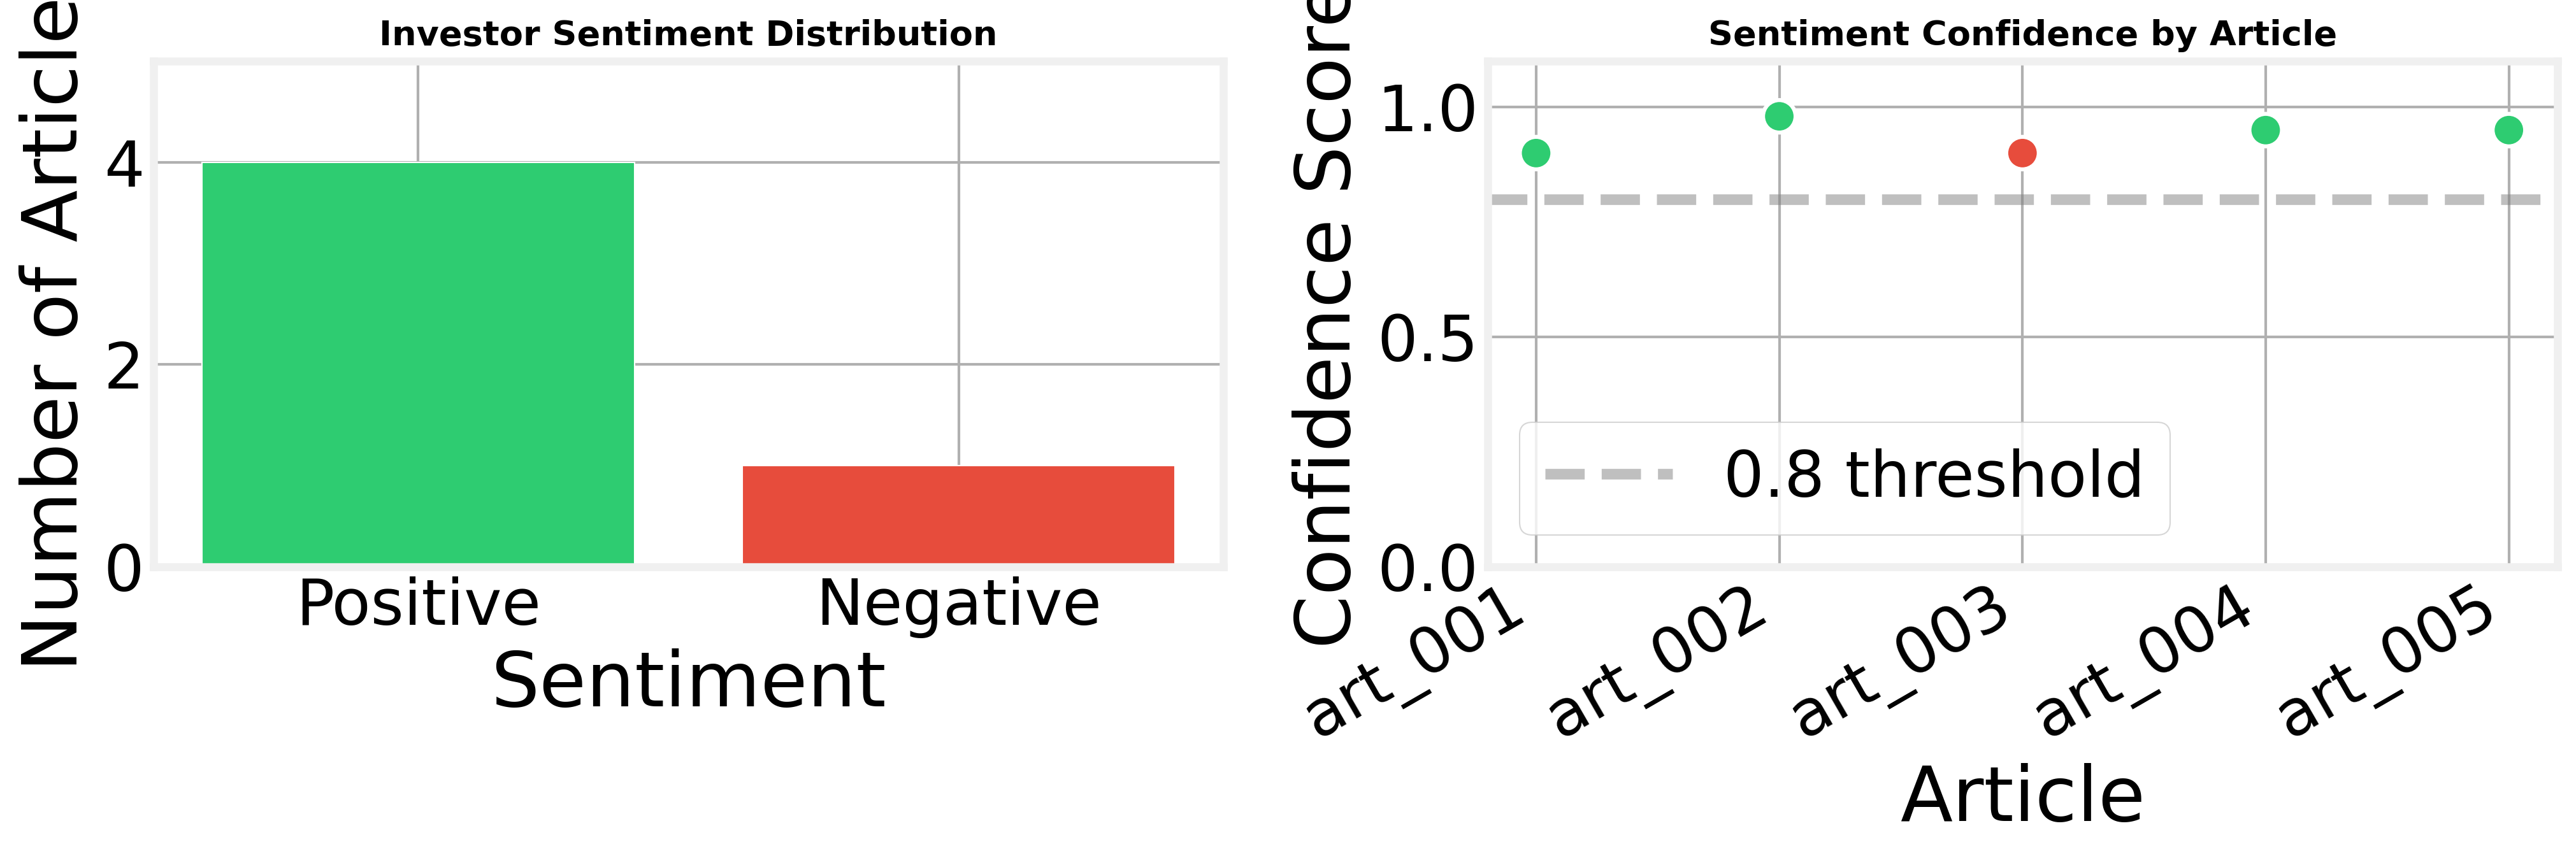

Figure saved to sentiment_analysis.png


In [31]:
# --- Plot 1: Sentiment distribution across articles ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment bar chart
sentiment_counts = sentiment_df["sentiment"].value_counts()
colors = {"Positive": "#2ecc71", "Negative": "#e74c3c",
          "Neutral": "#95a5a6", "Mixed": "#f39c12"}
bar_colors = [colors.get(s, "steelblue") for s in sentiment_counts.index]

axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors, edgecolor="white")
axes[0].set_title("Investor Sentiment Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of Articles")
axes[0].set_ylim(0, sentiment_counts.max() + 1)

# Confidence score scatter
sent_color_list = [colors.get(s, "steelblue") for s in sentiment_df["sentiment"]]
axes[1].scatter(
    range(len(sentiment_df)),
    sentiment_df["confidence"],
    c=sent_color_list, s=150, zorder=3, edgecolors="white", linewidths=1.5
)
axes[1].set_xticks(range(len(sentiment_df)))
axes[1].set_xticklabels(
    [f"art_{i+1:03d}" for i in range(len(sentiment_df))], rotation=30, ha="right"
)
axes[1].set_title("Sentiment Confidence by Article", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Article")
axes[1].set_ylabel("Confidence Score")
axes[1].set_ylim(0, 1.1)
axes[1].axhline(0.8, linestyle="--", color="gray", alpha=0.5, label="0.8 threshold")
axes[1].legend()

plt.tight_layout()
plt.savefig("sentiment_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to sentiment_analysis.png")

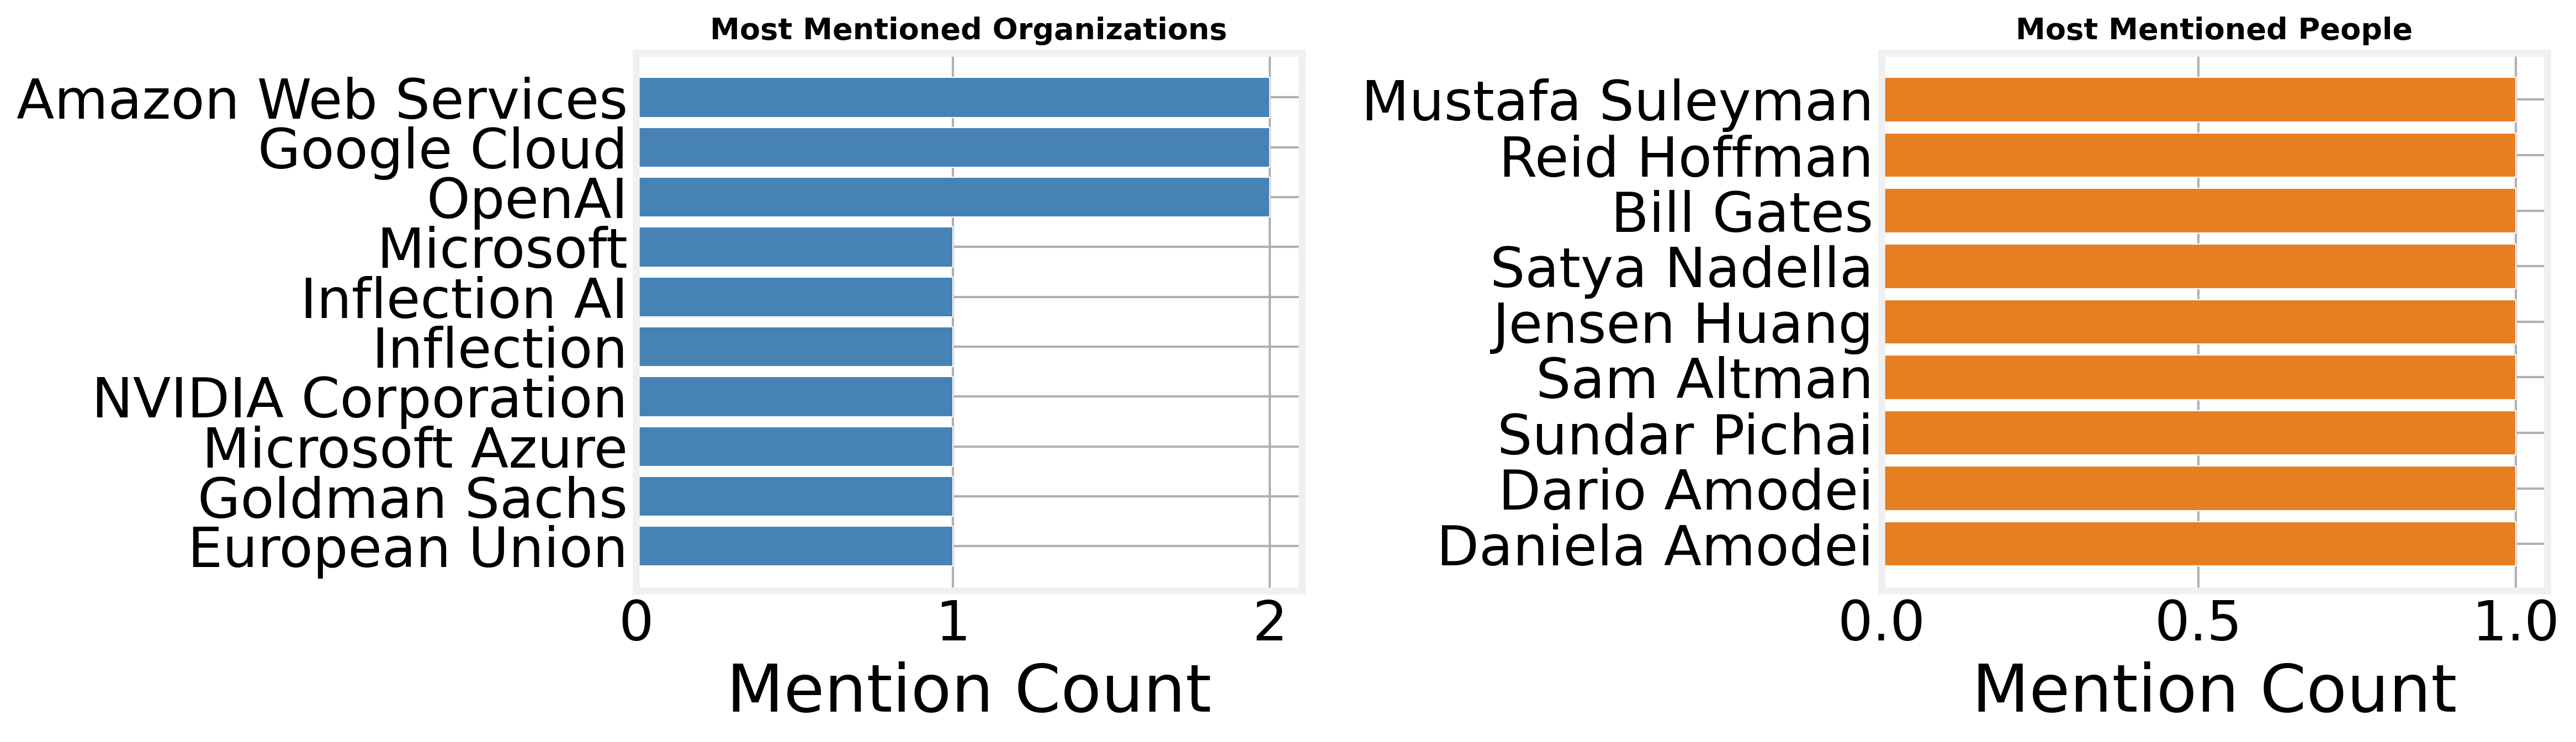

Figure saved to entity_frequency.png


In [32]:
# --- Plot 2: Most frequently mentioned organizations and people ---
# Flatten organization lists from NER results
all_orgs = []
all_people = []

for _, row in ner_df.iterrows():
    all_orgs.extend(row.get("organizations", []))
    all_people.extend(row.get("people", []))

org_counts = Counter(all_orgs).most_common(10)
people_counts = Counter(all_people).most_common(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Organizations
if org_counts:
    orgs, org_vals = zip(*org_counts)
    axes[0].barh(orgs[::-1], org_vals[::-1], color="steelblue", edgecolor="white")
    axes[0].set_title("Most Mentioned Organizations", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Mention Count")

# People
if people_counts:
    people, people_vals = zip(*people_counts)
    axes[1].barh(people[::-1], people_vals[::-1], color="#e67e22", edgecolor="white")
    axes[1].set_title("Most Mentioned People", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Mention Count")

plt.tight_layout()
plt.savefig("entity_frequency.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to entity_frequency.png")

In [33]:
# --- Summary table: combined NER + sentiment results ---
summary_df = sentiment_df[["id", "headline", "sentiment", "confidence"]].copy()

# Add entity counts from NER
if not ner_df.empty:
    ner_counts = ner_df[["id"]].copy()
    for key in NER_KEYS:
        ner_counts[f"n_{key}"] = ner_df[key].apply(lambda x: len(x) if isinstance(x, list) else 0)
    summary_df = summary_df.merge(ner_counts, on="id", how="left")

print("Combined Extraction Summary:")
print(summary_df.to_string(index=False))

Combined Extraction Summary:
     id                                                       headline sentiment  confidence  n_people  n_organizations  n_locations  n_monetary_values  n_dates
art_001      Microsoft Acquires AI Startup Inflection for $650 Million  Positive        0.90         4                3            2                  2        2
art_002         NVIDIA Reports Record Revenue as AI Chip Demand Surges  Positive        0.98         1                5            1                  3        0
art_003         OpenAI Faces Regulatory Scrutiny Over Safety Practices  Negative        0.90         1                5            1                  0        0
art_004 Google DeepMind Releases Gemini 1.5 with Million-Token Context  Positive        0.95         1                5            1                  0        0
art_005      AI Startup Anthropic Secures $2.75B in Amazon Partnership  Positive        0.95         2                4            1                  2        0


# Hands-On Exercises

Try the following exercises to reinforce what you've learned in this segment:

**Exercise 1 – Prompt Engineering**  
Take the `review_text` defined in Section 1.6 and write a new system prompt that instructs the model to respond in Spanish. Run it and compare the output with the English version.

**Exercise 2 – Chat Conversation**  
Start a new `chat` session and build a 5-turn conversation about a data science topic of your choice. After each turn, print `len(chat.history)` to watch the history grow.

**Exercise 3 – Temperature Exploration**  
Run the creative tagline prompt from Section 2.6 with temperatures 0.0, 0.5, 1.0, and 2.0, generating 5 responses at each setting. Plot the character-length distribution for each temperature.

**Exercise 4 – Custom NER Schema**  
Modify `ner_model`'s system instruction to also extract `'products'` and `'financial_figures'`. Re-run extraction on `articles[1]` (the NVIDIA article) and inspect the new fields.

**Exercise 5 – End-to-End Pipeline**  
Find a real news article online, paste it into a Python string, and run it through both the NER and sentiment pipelines. Create a one-row DataFrame from the combined output.

In [34]:
# Exercise workspace — add your solutions here


<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>